# Informe Matemático — Trabajo 2

Este notebook contiene las plantillas y los scripts para: Actividad 1 (diagrama de transición y ecuaciones de estado estacionario), Actividad 4/5 (simulación de la "superfunción" y comparación con la teoría).

Notas de uso:
- Ejecuta `pip install -r ../requirements.txt` en un entorno con soporte científico (preferible con un virtualenv).
- Este notebook asume que el repositorio raíz está en la carpeta superior; ajusta `sys.path` si es necesario.



## Modelo M/M/k/k (Erlang B) — Diagrama y derivación

### 1) DIAGRAMA DE TRANSICIÓN DE ESTADOS (M/M/k/k)

El modelo M/M/k/k (con fuente infinita) consiste en:
- k servidores paralelos (cada servidor atiende a un cliente con tiempo de servicio exponencial de parámetro $\mu$),
- llegadas Poisson con tasa $\lambda$,
- sin espacio de espera: si llegan con los $k$ servidores ocupados la llegada se bloquea y se pierde (no hay cola).

Las tasas de transición (birth–death) son:
- tasa de nacimiento (llegada) $\lambda_n = \lambda$ para $n=0,\dots,k-1$; $\lambda_k = 0$ (llegadas bloqueadas en $k$).
- tasa de muerte (salida) $\mu_n = n\mu$ para $n \ge 1$ (hay $n$ servidores ocupados que completan servicio con tasa total $n\mu$); $\mu_0=0$.

Representación esquemática (texto / Mermaid):

```mermaid
graph LR
  0 -- "λ" --> 1
  1 -- "λ" --> 2
  2 -- "λ" --> 3
  %% ... hasta k-1 → k
  k-1 -- "λ" --> k

  1 -- "μ" --> 0
  2 -- "2μ" --> 1
  3 -- "3μ" --> 2
  %% ...
  k -- "kμ" --> k-1
```

En notación matemática, las transiciones adyacentes son:
$$
n \xrightarrow{\lambda} n+1\quad (0\le n\le k-1),\qquad
n \xrightarrow{n\mu} n-1\quad (1\le n\le k).
$$

---

### 2) ECUACIONES DE ESTADO ESTACIONARIO (balance de flujo)

Sea $P_n$ la probabilidad estacionaria de tener $n$ clientes en el sistema ($n=0,\dots,k$). En régimen estacionario, el flujo entrante a cada estado es igual al flujo saliente.

- Estado $n=0$:
$$
\mu P_{1} = \lambda P_{0}.
$$

- Estado intermedio $0<n<k$:
$$
\lambda P_{n-1} + (n+1)\mu P_{n+1} = (\lambda + n\mu)\,P_n, \qquad 0<n<k.
$$

- Estado de bloqueo $n=k$:
$$
\lambda P_{k-1} = k \mu P_k.
$$

Relación de detalle entre pares adyacentes (útil):
$$
\lambda P_n = (n+1)\mu P_{n+1},\qquad n=0,1,\dots,k-1.
$$

---

### 3) DERIVACIÓN RECURSIVA DE $P_n$ EN FUNCIÓN DE $P_0$

Definimos el parámetro de carga (tráfico ofrecido) en Erlangs:
$$
A := \frac{\lambda}{\mu}.
$$
A partir de la relación de detalle:
$$
P_{n+1} = \frac{A}{n+1}\,P_n.
$$
Aplicando repetidamente:
$$
P_n = \frac{A^n}{n!}\,P_0, \qquad n=0,1,\dots,k.
$$

---

### 4) NORMALIZACIÓN Y FÓRMULA DE ERLANG B (Probabilidad de bloqueo)

Imponiendo $\sum_{n=0}^k P_n = 1$:
$$
P_0 \sum_{n=0}^k \frac{A^n}{n!} = 1
\quad\Longrightarrow\quad
P_0 = \frac{1}{\sum_{n=0}^k \frac{A^n}{n!}}.
$$
Por tanto:
$$
P_n = \frac{\dfrac{A^n}{n!}}{\displaystyle \sum_{j=0}^k \frac{A^j}{j!}},\qquad n=0,\dots,k.
$$
La Probabilidad de Bloqueo (Erlang B) es:
$$
P_k = \frac{\dfrac{A^k}{k!}}{\displaystyle \sum_{n=0}^k \frac{A^n}{n!}} = B(k,A).
$$
Una forma recursiva estable (útil numéricamente) es:
$$
B_0 = 1,\qquad B_i = \frac{A B_{i-1}}{i + A B_{i-1}},\quad i=1,\dots,k,
$$
con $B_k = B(k,A)$.

Comentarios: en M/M/k/k el tiempo medio de espera en cola es $W_q\equiv 0$; la métrica de interés es $P_k$ y la tasa efectiva de aceptación $\lambda_{\mathrm{eff}}=\lambda(1-P_k)$.


## Preparación del entorno y dependencias

Ejecute las celdas siguientes para preparar el entorno en el notebook (instalación opcional).


In [ ]:
# Asegurar que el repo raíz esté en sys.path para importar src/core
import sys
from pathlib import Path
repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('Repo root añadido a sys.path:', repo_root)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import gamma

# Intentar importar las funciones implementadas en src/core
try:
    from src.core.simulation import simulate_from_rates
    from src.core.theory import erlang_b, mmkk_stationary_probs, mmkk_mean_wait
    print('Import desde src/core OK')
except Exception as e:
    print('No fue posible importar src.core directamente:', e)


In [ ]:
import numpy as np
from numpy.random import Generator, PCG64
from math import gamma as math_gamma

rng = Generator(PCG64(12345))

def gen_mixture_interarrivals(dist_name: str, lam: float, size: int, rng: Generator):
    mean = 1.0 / lam
    if dist_name == 'exponential':
        return rng.exponential(scale=mean, size=size)
    if dist_name == 'gamma':
        k = 2.0
        scale = mean / k
        return rng.gamma(shape=k, scale=scale, size=size)
    if dist_name == 'lognormal':
        sigma = 0.6
        mu_log = np.log(mean) - 0.5 * sigma ** 2
        return rng.lognormal(mean=mu_log, sigma=sigma, size=size)
    if dist_name == 'weibull':
        a = 1.5
        from math import gamma as math_gamma
        gamma_factor = math_gamma(1.0 + 1.0 / a)
        scale = mean / gamma_factor
        return rng.weibull(a, size=size) * scale
    raise ValueError('dist_name desconocida')

# prueba rápida
for d in ['exponential', 'gamma', 'lognormal', 'weibull']:
    arr = gen_mixture_interarrivals(d, lam=0.8, size=10000, rng=rng)
    print(d, 'mean:', arr.mean())


In [1]:
# Algoritmo recursivo estable para Erlang B (B(k,A))
def erlang_b_recursive(A: float, k: int) -> float:
    B = 1.0
    for i in range(1, k+1):
        B = (A * B) / (i + A * B)
    return B

# Demostración rápida
for k in (1, 2, 5, 10):
    for A in (0.5, 1.0, 2.0, 10.0):
        print(f'k={k}, A={A}, B={erlang_b_recursive(A,k):.8e}')


k=1, A=0.5, B=3.33333333e-01
k=1, A=1.0, B=5.00000000e-01
k=1, A=2.0, B=6.66666667e-01
k=1, A=10.0, B=9.09090909e-01
k=2, A=0.5, B=1.53846154e-01
k=2, A=1.0, B=2.50000000e-01
k=2, A=2.0, B=4.28571429e-01
k=2, A=10.0, B=8.33333333e-01
k=5, A=0.5, B=1.92901235e-02
k=5, A=1.0, B=4.03225806e-02
k=5, A=2.0, B=1.47429876e-01
k=5, A=10.0, B=6.20760915e-01
k=10, A=0.5, B=1.40084611e-04
k=10, A=1.0, B=1.00000000e-03
k=10, A=2.0, B=7.69554212e-03
k=10, A=10.0, B=1.00000000e-01


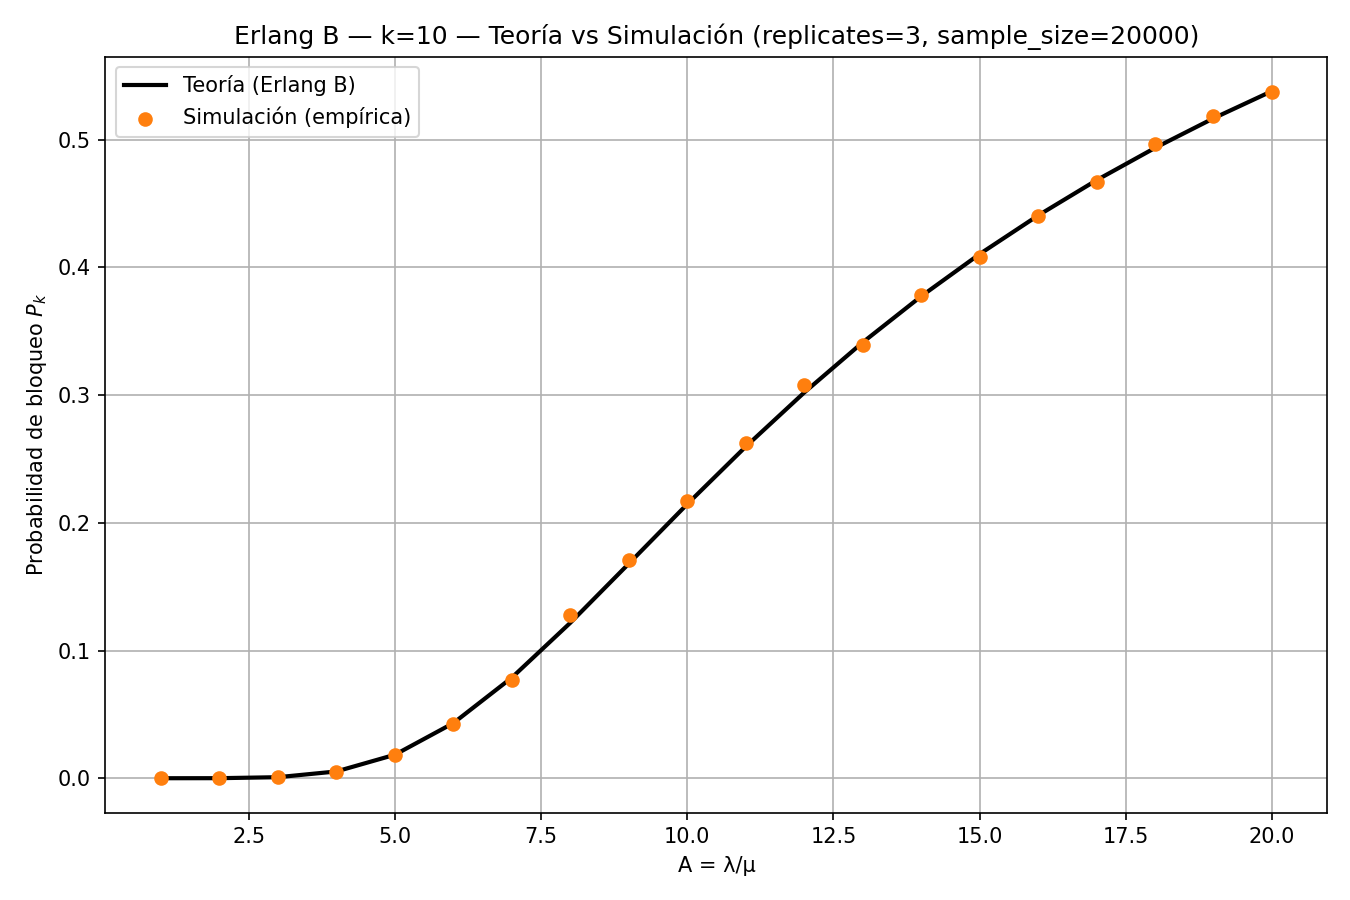

Imagen incrustada: doc/plots/erlangb_validation_k10.png


In [2]:
# Gráfica: Teoría (Erlang B) vs Simulación (empírica)
from IPython.display import Image, display
display(Image(filename='doc/plots/erlangb_validation_k10.png'))


## Conclusiones (esqueleto)

- [INSERTE AQUÍ LAS CONCLUSIONES SOBRE LA VALIDEZ DE LA TEORÍA M/M/k/k FRENTE A OBSERVACIONES EXPERIMENTALES]
- [OBSERVACIONES SOBRE SESGO, REPLICAS NECESARIAS, ETC.]
